In [1]:
import pandas as pd
import networkx as nx
import pickle

In [6]:
# paths
ADJ_PATH = "../burn_results/network_inference/FollowUp__Alive__n35__top1500__Q200__bperc0.65__lam0.05-0.3x20__inferred__adjacency.csv"

# load adjacency
adj = pd.read_csv(ADJ_PATH, index_col=0)

# create graph (undirected)
G = nx.from_pandas_adjacency(adj)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", nx.density(G))

Nodes: 1500
Edges: 69008
Density: 0.061381365354680896


In [ ]:
degrees = dict(G.degree())
deg_series = pd.Series(degrees)

print(deg_series.describe())
# mean degree, max degree, heavy-tailed/uniform distribution

count    1500.000000
mean       92.010667
std        22.450001
min        41.000000
25%        75.000000
50%        88.000000
75%       106.000000
max       195.000000
dtype: float64


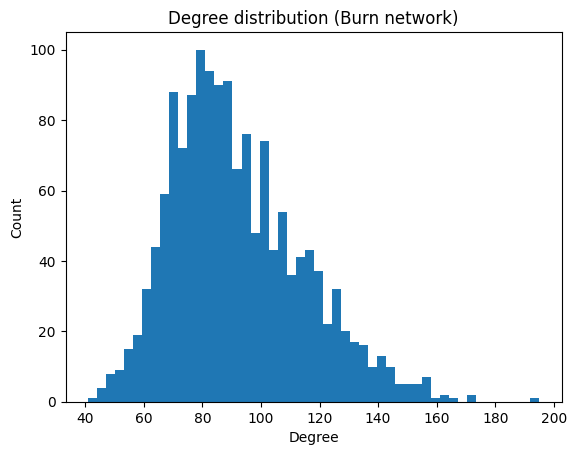

In [8]:
import matplotlib.pyplot as plt

plt.hist(deg_series, bins=50)
plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Degree distribution (Burn network)")
plt.show()

In [10]:
components = list(nx.connected_components(G))
component_sizes = sorted([len(c) for c in components], reverse=True)

print("Number of components:", len(components))
print("Largest component size:", component_sizes[0])

clustering = nx.average_clustering(G)
print("Average clustering coefficient:", clustering)

Number of components: 1
Largest component size: 1500
Average clustering coefficient: 0.1107563937857466


In [ ]:
deg_cent = nx.degree_centrality(G) # degree centrality
bet_cent = nx.betweenness_centrality(G) # betweenness
eig_cent = nx.eigenvector_centrality(G, max_iter=2000) # eigenvector centrality

#control-point table
control_df = pd.DataFrame({
    "degree": pd.Series(degrees),
    "degree_centrality": pd.Series(deg_cent),
    "betweenness": pd.Series(bet_cent),
    "eigenvector": pd.Series(eig_cent),
})

control_df["rank_degree"] = control_df["degree"].rank(ascending=False)
control_df["rank_betweenness"] = control_df["betweenness"].rank(ascending=False)
control_df["rank_eigenvector"] = control_df["eigenvector"].rank(ascending=False)

# simple aggregate score
control_df["control_score"] = (
    control_df["rank_degree"]
    + control_df["rank_betweenness"]
    + control_df["rank_eigenvector"]
)

control_df = control_df.sort_values("control_score")

#extract control points
top_controls = control_df.head(20)
print(top_controls)

# save as .csv
# top_controls.to_csv(
#     "burn_results/network_inference/FollowUp__Alive__top_control_genes.csv"
# )


                degree  degree_centrality  betweenness  eigenvector   
KCNQ1OT1           195           0.130087     0.002961     0.052357  \
XLOC_013712        173           0.115410     0.002428     0.046094   
CADM2              172           0.114743     0.002016     0.048904   
RBM19              165           0.110073     0.001939     0.045776   
IFNB1              162           0.108072     0.001790     0.046150   
SCN2B              162           0.108072     0.001932     0.044210   
NSMCE2             161           0.107405     0.001876     0.044678   
XLOC_013093        158           0.105404     0.001785     0.043445   
SLC9A3             156           0.104069     0.001745     0.043586   
XLOC_001813        156           0.104069     0.001771     0.043029   
SPO11              155           0.103402     0.001796     0.041997   
SHPK               155           0.103402     0.001704     0.043191   
XLOC_002725        156           0.104069     0.001606     0.044368   
CXCL9 